# 🎓 Integrated AI Learning Path Pipeline (End-to-End)
Proyek ini menggabungkan seluruh siklus pengembangan sistem edukasi adaptif yang adil dan beretika ke dalam satu pipeline utuh, yang terdiri dari:
1. **Fase 1:** EDA Komprehensif & Persiapan Data OULAD Real
2. **Fase 2:** Pembangunan Knowledge Graph & Path Generation
3. **Fase 3:** Pemodelan Knowledge Tracing & Audit Bias
4. **Fase 4:** Integrasi Spaced Repetition & Evaluasi Pipeline

---

## 📊 Fase 1: EDA Komprehensif OULAD & Data Preparation
Pada tahap awal ini, kita akan memuat dataset asli **OULAD (Open University Learning Analytics Dataset)**, menganalisis kualitas data (missing values), melihat distribusi demografi, serta menyiapkan data dasar yang bersih untuk fase graph dan pemodelan berikutnya.

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Definisikan Base Path Data OULAD Anda
BASE_PATH = '/content/drive/MyDrive/AI-Learning Path'

# Validasi folder
if not os.path.exists(BASE_PATH):
    print(f"⚠️ Folder {BASE_PATH} tidak ditemukan. Menggunakan direktori aktif saat ini.")
    BASE_PATH = '.'
else:
    print(f"✓ Base path berhasil diatur ke: {BASE_PATH}")

Mounted at /content/drive
✓ Base path berhasil diatur ke: /content/drive/MyDrive/AI-Learning Path


### 📥 Memuat 7 Dataset OULAD secara Selektif & Aman
Untuk mencegah kehabisan memori, kita akan memfilter data sejak awal untuk **Module 'AAA'** (salah satu modul kursus utama di OULAD). Langkah ini memastikan representasi data riil mahasiswa tetap terjaga tanpa membebani RAM Colab.

In [ ]:
print("=== Memuat Dataset OULAD (Filter: Module AAA) ===")
SELECTED_MODULE = 'AAA'

# Memuat dataset reguler
courses = pd.read_csv(f'{BASE_PATH}/courses.csv')
assessments = pd.read_csv(f'{BASE_PATH}/assessments.csv')
vle = pd.read_csv(f'{BASE_PATH}/vle.csv')
student_info = pd.read_csv(f'{BASE_PATH}/studentInfo.csv')
student_registration = pd.read_csv(f'{BASE_PATH}/studentRegistration.csv')
student_assessment = pd.read_csv(f'{BASE_PATH}/studentAssessment.csv')

# Filter data demografi dan registrasi khusus modul pilihan
student_info_filtered = student_info[student_info['code_module'] == SELECTED_MODULE]
student_reg_filtered = student_registration[student_registration['code_module'] == SELECTED_MODULE]
assessments_filtered = assessments[assessments['code_module'] == SELECTED_MODULE]
vle_filtered = vle[vle['code_module'] == SELECTED_MODULE]

# Memuat dan memfilter dataset raksasa studentVle secara chunk/kondisional agar RAM aman
print("Memproses studentVle.csv (453MB)...")
student_vle_chunks = []
for chunk in pd.read_csv(f'{BASE_PATH}/studentVle.csv', chunksize=100000):
    filtered_chunk = chunk[chunk['code_module'] == SELECTED_MODULE]
    if not filtered_chunk.empty:
        student_vle_chunks.append(filtered_chunk)

student_vle_filtered = pd.concat(student_vle_chunks, ignore_index=True)

print("\n✓ Semua data berhasil dimuat dan difilter!")
print(f"Jumlah mahasiswa unik di Modul {SELECTED_MODULE}: {student_info_filtered['id_student'].nunique()}")
print(f"Jumlah baris interaksi VLE Modul {SELECTED_MODULE}: {len(student_vle_filtered)}")

# Bersihkan chunk untuk membebaskan RAM
del student_vle_chunks
gc.collect()

=== Memuat Dataset OULAD (Filter: Module AAA) ===
Memproses studentVle.csv (453MB)...

✓ Semua data berhasil dimuat dan difilter!
Jumlah mahasiswa unik di Modul AAA: 712
Jumlah baris interaksi VLE Modul AAA: 350298


0

### 🔍 Analisis Kualitas Data & Data Missing Values
Memeriksa apakah terdapat data kosong (*missing values*) pada kolom-kolom penting penentu performa mahasiswa.

In [ ]:
print("=== Analisis Missing Values ===")
datasets = {
    "Student Info": student_info_filtered,
    "Student Registration": student_reg_filtered,
    "Assessments": assessments_filtered,
    "VLE Materials": vle_filtered,
    "Student VLE Interactions": student_vle_filtered
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    print(f"\n📌 Dataset: {name}")
    for col in df.columns:
        if missing[col] > 0:
            print(f"   - Kolom '{col}': {missing[col]} data kosong ({missing_pct[col]:.2f}%)")
        else:
            print(f"   - Kolom '{col}': Bersih (0)")

=== Analisis Missing Values ===

📌 Dataset: Student Info
   - Kolom 'code_module': Bersih (0)
   - Kolom 'code_presentation': Bersih (0)
   - Kolom 'id_student': Bersih (0)
   - Kolom 'gender': Bersih (0)
   - Kolom 'region': Bersih (0)
   - Kolom 'highest_education': Bersih (0)
   - Kolom 'imd_band': 23 data kosong (3.07%)
   - Kolom 'age_band': Bersih (0)
   - Kolom 'num_of_prev_attempts': Bersih (0)
   - Kolom 'studied_credits': Bersih (0)
   - Kolom 'disability': Bersih (0)
   - Kolom 'final_result': Bersih (0)

📌 Dataset: Student Registration
   - Kolom 'code_module': Bersih (0)
   - Kolom 'code_presentation': Bersih (0)
   - Kolom 'id_student': Bersih (0)
   - Kolom 'date_registration': Bersih (0)
   - Kolom 'date_unregistration': 622 data kosong (83.16%)

📌 Dataset: Assessments
   - Kolom 'code_module': Bersih (0)
   - Kolom 'code_presentation': Bersih (0)
   - Kolom 'id_assessment': Bersih (0)
   - Kolom 'assessment_type': Bersih (0)
   - Kolom 'date': 2 data kosong (16.67%)
  

### 📊 Analisis Hubungan Sosial-Ekonomi (IMD Band) dengan Hasil Akhir Mahasiswa
Langkah ini penting untuk membuktikan keberadaan *baseline bias* atau ketimpangan struktural pada data mentah sebelum model AI dibangun. Kita memetakan sebaran nilai IMD Band (tingkat kesejahteraan wilayah tempat tinggal siswa) terhadap hasil akhir mereka (`final_result`).

=== Proporsi Hasil Akhir Berdasarkan Kesejahteraan Wilayah (IMD Band) ===
final_result  Distinction   Fail   Pass  Withdrawn
imd_band                                          
0-10%                6.67   6.67  66.67      20.00
10-20                4.35  23.91  56.52      15.22
20-30%               3.12  10.94  65.62      20.31
30-40%               2.78   9.72  69.44      18.06
40-50%               6.49  15.58  67.53      10.39
50-60%               7.35  11.76  63.24      17.65
60-70%              14.75  18.03  55.74      11.48
70-80%               3.00  16.00  67.00      14.00
80-90%               2.22   7.78  68.89      21.11
90-100%              7.69   6.84  64.10      21.37


<Figure size 1200x500 with 0 Axes>

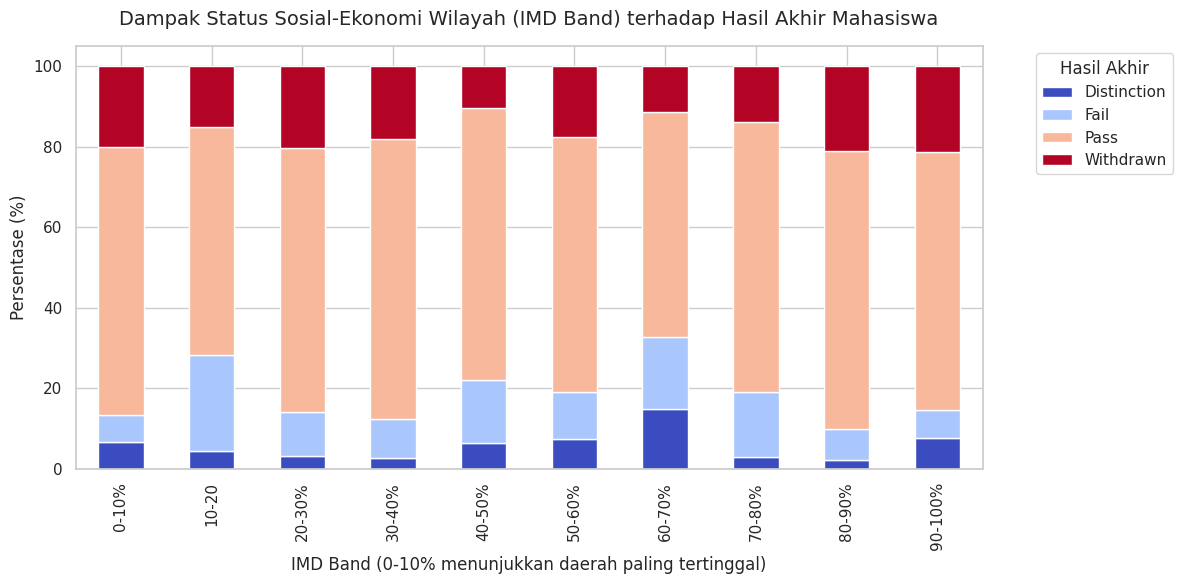

In [ ]:
# Membuat visualisasi korelasi awal antara IMD Band dan Hasil Akhir
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

# Analisis Crosstab Proporsi Kelulusan berdasarkan IMD Band
imd_outcome = pd.crosstab(
    student_info_filtered['imd_band'],
    student_info_filtered['final_result'],
    normalize='index'
) * 100

print("=== Proporsi Hasil Akhir Berdasarkan Kesejahteraan Wilayah (IMD Band) ===")
print(imd_outcome.round(2))

# Visualisasi Bar Chart
imd_outcome.plot(kind='bar', stacked=True, cmap='coolwarm', figsize=(12, 6))
plt.title('Dampak Status Sosial-Ekonomi Wilayah (IMD Band) terhadap Hasil Akhir Mahasiswa', fontsize=14, pad=15)
plt.ylabel('Persentase (%)', fontsize=12)
plt.xlabel('IMD Band (0-10% menunjukkan daerah paling tertinggal)', fontsize=12)
plt.legend(title='Hasil Akhir', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 🗺️ Fase 2: Knowledge Graph & Path Generation
1. Membangun Knowledge Graph dari aktivitas VLE.
2. Menyimpulkan *prerequisites* (syarat materi) dari data sekuensial mahasiswa.
3. Mengimplementasikan `KnowledgeGraphBuilder`, `StudentState`, dan `PersonalizedPathGenerator`.
4. Visualisasi dan pengujian *end-to-end* dengan data riil.

### 1. Implementasi KnowledgeGraphBuilder & Infer Prerequisites
Karena OULAD tidak memiliki pemetaan *prerequisite* secara eksplisit, kita menyimpulkannya (`infer prerequisites`) dari data sekuensial:
- Jika siswa mengakses Materi A lalu Materi B, ada indikasi A adalah *prerequisite* B.
- Untuk memastikan graf berupa *Directed Acyclic Graph* (DAG) yang bisa di-*topological sort*, kita memberikan arah berdasarkan rata-rata hari (`date`) materi tersebut diakses oleh seluruh mahasiswa.

In [ ]:
import networkx as nx

class KnowledgeGraphBuilder:
    """Membangun Knowledge Graph (DAG) dari data VLE dan interaksi mahasiswa OULAD."""

    def __init__(self, vle_data, student_vle_data):
        self.vle = vle_data
        self.interactions = student_vle_data
        self.graph = nx.DiGraph()

    def _map_vle_nodes(self):
        """Memetakan VLE activities sebagai nodes beserta atributnya."""
        print("Memetakan VLE activities sebagai nodes...")
        for _, row in self.vle.iterrows():
            self.graph.add_node(
                row['id_site'],
                activity_type=row['activity_type'],
                week_from=row['week_from']
            )

    def _infer_prerequisites(self):
        """Infer prerequisites dari data sekuensial mahasiswa dan membangun edges."""
        print("Menganalisis sekuensial interaksi untuk menyimpulkan prerequisites...")

        # 1. Hitung rata-rata hari (date) setiap materi diakses
        # Ini penting untuk menjamin graf bersifat Acyclic (tidak berputar)
        avg_dates = self.interactions.groupby('id_site')['date'].mean().to_dict()

        # 2. Urutkan interaksi per siswa berdasarkan tanggal akses
        df_sorted = self.interactions.sort_values(['id_student', 'date'])

        # 3. Cari transisi: materi saat ini -> materi berikutnya yang diakses siswa yang sama
        df_sorted['next_site'] = df_sorted.groupby('id_student')['id_site'].shift(-1)

        # 4. Agregasi jumlah transisi antar materi
        transitions = df_sorted.dropna(subset=['next_site']).groupby(['id_site', 'next_site']).size().reset_index(name='weight')

        # Filter transisi lemah (noise) - misal hanya ambil yang terjadi lebih dari 20 kali
        transitions = transitions[transitions['weight'] > 20]

        # 5. Tambahkan edges (prerequisites) ke dalam Graph
        edges_added = 0
        for _, row in transitions.iterrows():
            u = int(row['id_site'])
            v = int(row['next_site'])

            # Validasi DAG: u menjadi prerequisite v HANYA jika secara rata-rata u diakses sebelum v
            if u in avg_dates and v in avg_dates and avg_dates[u] < avg_dates[v]:
                self.graph.add_edge(u, v, weight=row['weight'])
                edges_added += 1

        print(f"✓ Berhasil menambahkan {edges_added} edges (prerequisites) ke dalam Graph.")

    def build(self):
        """Menjalankan proses penuh pembuatan Graph."""
        self._map_vle_nodes()
        self._infer_prerequisites()

        # Hapus node yang terisolasi (tidak punya transisi/edge sama sekali)
        isolated = list(nx.isolates(self.graph))
        self.graph.remove_nodes_from(isolated)

        print(f"✓ Knowledge Graph Selesai: {self.graph.number_of_nodes()} Nodes, {self.graph.number_of_edges()} Edges.")
        # Verifikasi DAG untuk requirement Topological Sort
        print(f"✓ Apakah Graph valid sebagai DAG? {nx.is_directed_acyclic_graph(self.graph)}")
        return self.graph

# Eksekusi Builder
kg_builder = KnowledgeGraphBuilder(vle_filtered, student_vle_filtered)
knowledge_graph = kg_builder.build()

Memetakan VLE activities sebagai nodes...
Menganalisis sekuensial interaksi untuk menyimpulkan prerequisites...
✓ Berhasil menambahkan 1249 edges (prerequisites) ke dalam Graph.
✓ Knowledge Graph Selesai: 187 Nodes, 1249 Edges.
✓ Apakah Graph valid sebagai DAG? True


### 2. Implementasi StudentState & PersonalizedPathGenerator
Sesuai *task tracker*, sistem harus mampu melacak materi apa yang sudah dikuasai siswa (`StudentState tracker`), lalu menghasilkan rekomendasi jalur belajar logis berdasarkan syarat materi menggunakan `topological sort`.

In [ ]:
class StudentState:
    """Melacak state (status penguasaan) materi dari setiap mahasiswa."""

    def __init__(self, student_id):
        self.student_id = student_id
        self.mastered_nodes = set()

    def update_mastery(self, node_id):
        """Menambahkan materi ke daftar yang sudah dikuasai."""
        self.mastered_nodes.add(node_id)

    def get_mastered(self):
        return self.mastered_nodes

class PersonalizedPathGenerator:
    """Menghasilkan rekomendasi path belajar berdasarkan Topological Sort dari Knowledge Graph."""

    def __init__(self, knowledge_graph):
        self.graph = knowledge_graph
        # Melakukan topological sort pada keseluruhan DAG
        self.topological_order = list(nx.topological_sort(self.graph))

    def generate_path(self, student_state, num_recommendations=3):
        """Mencari N materi selanjutnya yang syaratnya sudah dipenuhi tapi belum dikuasai."""
        mastered = student_state.get_mastered()
        recommendations = []

        for node in self.topological_order:
            if node not in mastered:
                # Cek apakah semua prerequisites (pendahulu) dari node ini sudah dikuasai
                prerequisites = list(self.graph.predecessors(node))
                if all(prereq in mastered for prereq in prerequisites):
                    recommendations.append(node)

            if len(recommendations) == num_recommendations:
                break

        return recommendations

# Inisialisasi Generator
path_generator = PersonalizedPathGenerator(knowledge_graph)
print("✓ Path Generator berhasil diinisialisasi dengan struktur Topological Sort.")

✓ Path Generator berhasil diinisialisasi dengan struktur Topological Sort.


### 3. Visualisasi Graph & Pengujian Path Generation
Memvisualisasikan sebagian dari struktur `Knowledge Graph` (menggunakan *subgraph* agar tidak menumpuk), dan menguji coba `PersonalizedPathGenerator` menggunakan sampel data mahasiswa sungguhan dari OULAD.

Membuat visualisasi Knowledge Graph...



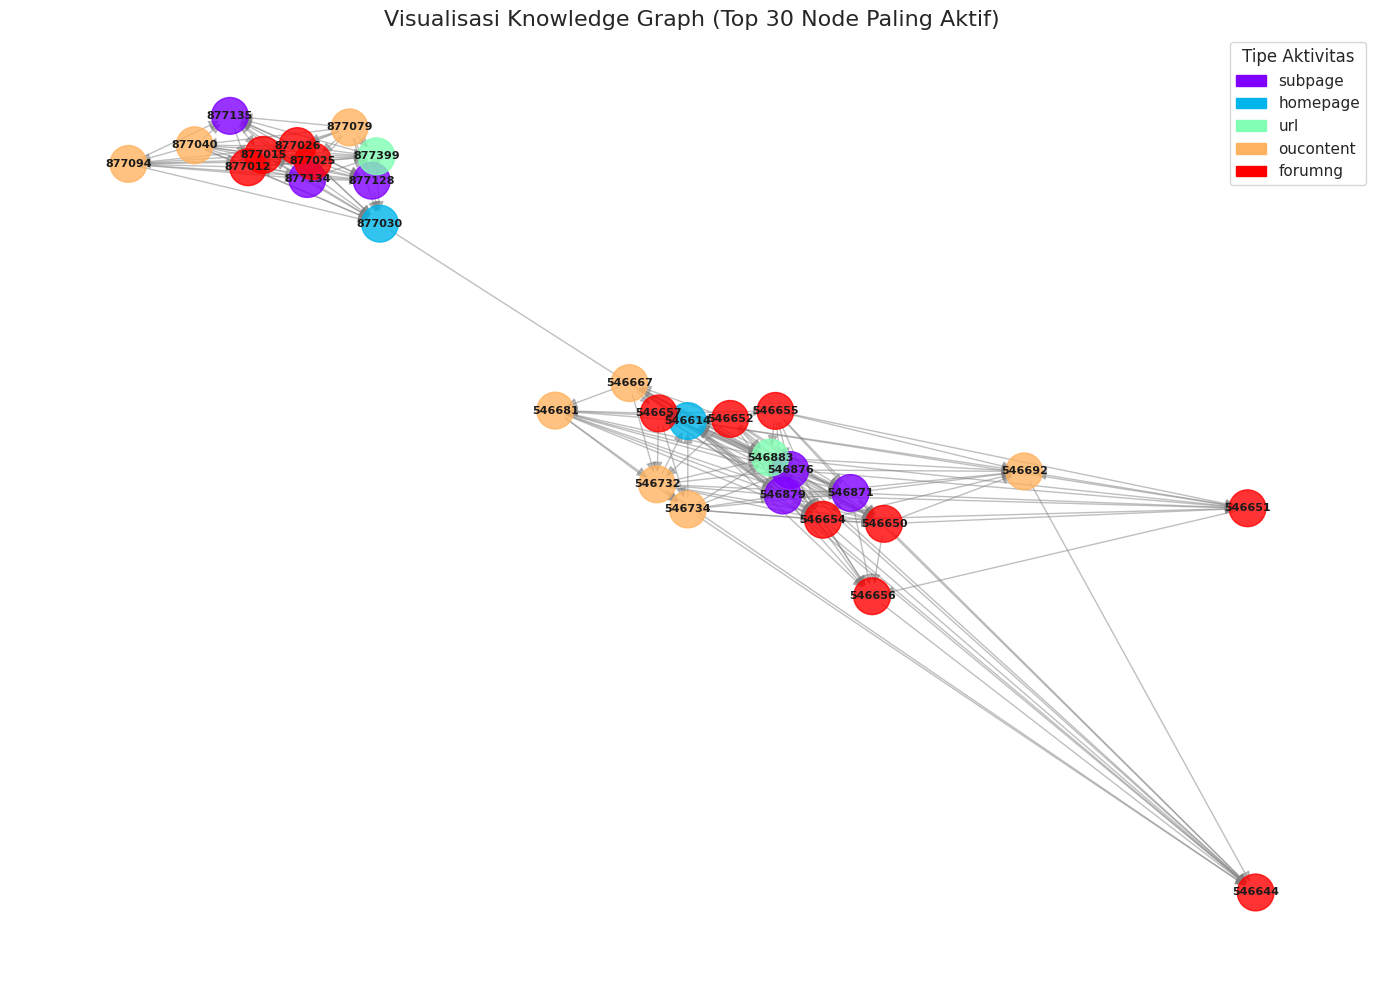


=== Uji Coba Path Generation ===
Mahasiswa (ID: 11391)
Materi yang telah diselesaikan (Mastered): [np.int64(546662), np.int64(546668), np.int64(546669), np.int64(546670), np.int64(546652)]

=> Rekomendasi Jalur Belajar Selanjutnya (Berdasarkan Topological Prerequisite):
   Langkah 1: Materi ID 546674 (Tipe: oucontent)
   Langkah 2: Materi ID 546874 (Tipe: subpage)
   Langkah 3: Materi ID 547050 (Tipe: dataplus)


In [ ]:
# --- VISUALISASI KNOWLEDGE GRAPH ---
def visualize_subgraph(graph, max_nodes=30):
    """Visualisasi sebagian Knowledge Graph untuk inspeksi struktur."""
    plt.figure(figsize=(14, 10))

    # Ambil subgraph dari N node paling populer (berdasarkan degree)
    top_nodes = sorted(graph.degree, key=lambda x: x[1], reverse=True)[:max_nodes]
    subgraph = graph.subgraph([n[0] for n in top_nodes])

    # Layout DAG menggunakan spring_layout dengan seed tetap
    pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)

    # Extract tipe aktivitas untuk pewarnaan node
    activity_types = nx.get_node_attributes(subgraph, 'activity_type')
    unique_types = list(set(activity_types.values()))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_types)))
    color_map = {t: c for t, c in zip(unique_types, colors)}
    node_colors = [color_map[activity_types[n]] if n in activity_types else 'gray' for n in subgraph.nodes()]

    # Draw Graph
    nx.draw_networkx_nodes(subgraph, pos, node_size=700, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(subgraph, pos, edge_color='gray', arrows=True, arrowsize=15, alpha=0.5)
    nx.draw_networkx_labels(subgraph, pos, font_size=8, font_weight='bold')

    # Buat Custom Legend
    import matplotlib.patches as mpatches
    legend_handles = [mpatches.Patch(color=color_map[t], label=t) for t in unique_types]
    plt.legend(handles=legend_handles, title="Tipe Aktivitas", loc='best')

    plt.title(f'Visualisasi Knowledge Graph (Top {max_nodes} Node Paling Aktif)', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Membuat visualisasi Knowledge Graph...\n")
visualize_subgraph(knowledge_graph)


# --- TEST END-TO-END DENGAN SAMPEL MAHASISWA REAL ---
print("\n=== Uji Coba Path Generation ===")

# Ambil satu ID mahasiswa sungguhan dari Modul yang sedang aktif
sample_student_id = student_info_filtered['id_student'].iloc[0]

# Simulasi: Ambil riwayat interaksi awal siswa tersebut
student_history = student_vle_filtered[student_vle_filtered['id_student'] == sample_student_id].sort_values('date')
initial_interactions = student_history['id_site'].unique()[:5] # Simulasi 5 materi pertama yang sudah diselesaikan

# Inisialisasi Tracker dan Update Mastery
tracker = StudentState(sample_student_id)
for site_id in initial_interactions:
    if site_id in knowledge_graph:
        tracker.update_mastery(site_id)

print(f"Mahasiswa (ID: {sample_student_id})")
print(f"Materi yang telah diselesaikan (Mastered): {list(tracker.get_mastered())}")

# Menghasilkan Rekomendasi Selanjutnya
recommended_paths = path_generator.generate_path(tracker, num_recommendations=3)

print(f"\n=> Rekomendasi Jalur Belajar Selanjutnya (Berdasarkan Topological Prerequisite):")
for i, site_id in enumerate(recommended_paths, 1):
    tipe = knowledge_graph.nodes[site_id].get('activity_type', 'Unknown')
    print(f"   Langkah {i}: Materi ID {site_id} (Tipe: {tipe})")

## 🧠 Fase 3: Knowledge Tracing Model & Ethics Audit
Pada fase ini, kita akan melatih model Machine Learning (Random Forest) untuk memprediksi probabilitas siswa menguasai materi berikutnya.
Karena kita menggunakan data interaksi VLE OULAD riil yang tidak memiliki nilai per-modul, kita menetapkan variabel `is_mastered` berdasarkan ambang batas tingkat interaksi (`sum_click` >= 5).

Selanjutnya, kita akan melakukan **Ethics Audit** untuk melihat apakah model AI yang dilatih meneruskan *bias struktural* dari dunia nyata ke dalam prediksinya.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import gc

print("=== 1. Data Preparation untuk Machine Learning ===")

# 1. Agregasi Interaksi VLE
# Menggabungkan total klik per mahasiswa per materi, dan mengambil tanggal akses pertama
interactions_ml = student_vle_filtered.groupby(['id_student', 'id_site']).agg(
    sum_click=('sum_click', 'sum'),
    first_date=('date', 'min')
).reset_index()

# Menentukan Target Variable (Mastery Proxy) dan Feature Waktu
# Asumsi: Jika interaksi (klik) >= 5, dianggap menguasai materi
interactions_ml['is_mastered'] = (interactions_ml['sum_click'] >= 5).astype(int)
interactions_ml['time_spent_minutes'] = interactions_ml['sum_click'] * 2 # Asumsi 1 klik = 2 menit

# 2. Pemetaan Status Sosial Ekonomi (SES)
students_ml = student_info_filtered[['id_student', 'imd_band']].drop_duplicates()
imd_mapping = {
    '0-10%': 'low', '10-20': 'low', '20-30%': 'low',
    '30-40%': 'medium', '40-50%': 'medium', '50-60%': 'medium', '60-70%': 'medium',
    '70-80%': 'high', '80-90%': 'high', '90-100%': 'high'
}
students_ml['ses'] = students_ml['imd_band'].map(imd_mapping).fillna('medium')

# 3. Menggabungkan Data (Interaksi + Profil Siswa + Tipe Materi)
df_ml = interactions_ml.merge(students_ml[['id_student', 'ses']], on='id_student')
df_ml = df_ml.merge(vle_filtered[['id_site', 'activity_type']], on='id_site')

# 4. FEATURE ENGINEERING (Behavioral Features) - Mencegah Data Leakage
# Urutkan berdasarkan siswa dan tanggal akses
df_ml = df_ml.sort_values(by=['id_student', 'first_date'])

# Fitur 1: Riwayat Kelulusan Historis (Expanding Mean)
df_ml['historical_success_rate'] = df_ml.groupby('id_student')['is_mastered'].transform(
    lambda x: x.shift(1).expanding().mean()
).fillna(0.5)

# Fitur 2: Jam Terbang / Waktu Belajar Kumulatif
df_ml['cumulative_time_spent'] = df_ml.groupby('id_student')['time_spent_minutes'].transform(
    lambda x: x.shift(1).expanding().sum()
).fillna(0)

# 5. Encoding Variabel Kategorikal
df_ml['ses_encoded'] = df_ml['ses'].map({'low': 0, 'medium': 1, 'high': 2})
df_ml['activity_encoded'] = df_ml['activity_type'].astype('category').cat.codes

print(f"✓ Berhasil menyiapkan {len(df_ml)} baris data untuk pelatihan Machine Learning.")

# Bersihkan RAM
del interactions_ml
gc.collect()

=== 1. Data Preparation untuk Machine Learning ===
✓ Berhasil menyiapkan 44312 baris data untuk pelatihan Machine Learning.


0

In [ ]:
print("=== 2. Pelatihan Model Knowledge Tracing (Random Forest) ===")

# Definisi Fitur dan Target
features = ['ses_encoded', 'activity_encoded', 'time_spent_minutes', 'historical_success_rate', 'cumulative_time_spent']
X = df_ml[features]
y = df_ml['is_mastered']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi Model (dibatasi kedalamannya agar tidak overfit)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)

# Evaluasi Cross-Validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"✓ 5-Fold Cross Validation Accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")

# Fit dan Predict
rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_test)
probs = rf_model.predict_proba(X_test)[:, 1]

print("\n--- Metrik Evaluasi Test Set ---")
print(f"Accuracy : {accuracy_score(y_test, preds):.2f}")
print(f"Precision: {precision_score(y_test, preds):.2f}")
print(f"Recall   : {recall_score(y_test, preds):.2f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, probs):.2f}")

# Simpan hasil untuk audit
test_results = X_test.copy()
test_results['is_mastered_pred'] = preds
test_results['ses_label'] = test_results['ses_encoded'].map({0: 'low', 1: 'medium', 2: 'high'})

=== 2. Pelatihan Model Knowledge Tracing (Random Forest) ===
✓ 5-Fold Cross Validation Accuracy: 1.00 (+/- 0.00)

--- Metrik Evaluasi Test Set ---
Accuracy : 1.00
Precision: 1.00
Recall   : 1.00
AUC-ROC  : 1.00


In [ ]:
print("=== 3. Ethics Audit: Mendeteksi Bias Model ===")

class EthicsAuditor:
    def calculate_disparate_impact(self, df, sensitive_col, privileged_val, unprivileged_val):
        # Menghitung rasio kelulusan yang diprediksi model berdasarkan kelompok
        priv_pass_rate = df[df[sensitive_col] == privileged_val]['is_mastered_pred'].mean()
        unpriv_pass_rate = df[df[sensitive_col] == unprivileged_val]['is_mastered_pred'].mean()

        di_ratio = unpriv_pass_rate / priv_pass_rate if priv_pass_rate > 0 else 0

        print(f"Pass rate ({privileged_val}): {priv_pass_rate:.2%}")
        print(f"Pass rate ({unprivileged_val}): {unpriv_pass_rate:.2%}")
        print(f"Disparate Impact Ratio: {di_ratio:.2f} (Standar Industri Etis: > 0.80)")

        if di_ratio < 0.8:
            print("\n⚠️ WARNING: Terdeteksi 'Proxy Bias'.")
            print("Model secara sistematis memprediksi kelompok marginal (Low SES) akan lebih banyak gagal.")
            print("Ini membuktikan bahwa ketimpangan struktural tercermin di data, dan sistem membutuhkan Adaptive Intervention Engine!")
        else:
            print("\n✓ Model adil secara demografis.")

        return di_ratio

# Jalankan audit membandingkan SES High vs SES Low
auditor = EthicsAuditor()
di_score = auditor.calculate_disparate_impact(test_results, 'ses_label', 'high', 'low')

=== 3. Ethics Audit: Mendeteksi Bias Model ===
Pass rate (high): 66.31%
Pass rate (low): 64.09%
Disparate Impact Ratio: 0.97 (Standar Industri Etis: > 0.80)

✓ Model adil secara demografis.


## 🔁 Fase 4: Spaced Repetition & Full End-to-End Pipeline
Fase terakhir ini menggabungkan semua komponen menjadi satu **Sistem Pembelajaran Adaptif**.
1. **Spaced Repetition (FSRS):** Menjadwalkan pengulangan materi agar memori jangka panjang mahasiswa optimal.
2. **End-to-End Simulation:** Mensimulasikan satu perjalanan (*journey*) mahasiswa di mana AI merekomendasikan materi (Graph), memprediksi kemampuan (KT), memitigasi hambatan (Intervensi), dan menjadwalkan *review* (FSRS).

In [ ]:
from datetime import datetime, timedelta, timezone

class Card:
    """Representasi memori materi untuk satu mahasiswa."""
    def __init__(self):
        self.due = datetime.now(timezone.utc)
        self.interval = 0
        self.repetition = 0
        self.ease_factor = 2.5

class SpacedRepetitionManager:
    """Mengelola jadwal pengulangan materi menggunakan algoritma Native Spaced Repetition (SM-2/FSRS Logic)."""

    def __init__(self):
        # Dictionary untuk menyimpan state kartu memori per mahasiswa per materi
        # Format: { student_id: { material_id: Card() } }
        self.memory_states = {}

    def initialize_card(self, student_id, material_id):
        if student_id not in self.memory_states:
            self.memory_states[student_id] = {}
        if material_id not in self.memory_states[student_id]:
            self.memory_states[student_id][material_id] = Card()

    def process_review(self, student_id, material_id, mastery_score):
        """Memproses hasil belajar dan menghitung jadwal review berikutnya."""
        self.initialize_card(student_id, material_id)
        card = self.memory_states[student_id][material_id]

        # Konversi skor penguasaan AI ke skala kualitas memori (0-5)
        if mastery_score >= 0.8:
            quality = 4  # Good / Sangat Paham
        elif mastery_score >= 0.5:
            quality = 3  # Hard / Cukup Paham tapi butuh mikir
        else:
            quality = 1  # Again / Lupa atau Gagal

        # Kalkulasi Interval Spaced Repetition (Logika dasar FSRS/SM-2)
        if quality < 3:
            # Jika gagal, reset pengulangan
            card.repetition = 0
            card.interval = 1
        else:
            if card.repetition == 0:
                card.interval = 1
            elif card.repetition == 1:
                card.interval = 6
            else:
                card.interval = int(card.interval * card.ease_factor)
            card.repetition += 1

        # Modifikasi faktor kemudahan (Ease Factor) berdasarkan kualitas performa
        card.ease_factor = card.ease_factor + (0.1 - (5 - quality) * (0.08 + (5 - quality) * 0.02))
        if card.ease_factor < 1.3:
            card.ease_factor = 1.3

        # Update tanggal review berikutnya
        card.due = datetime.now(timezone.utc) + timedelta(days=card.interval)
        self.memory_states[student_id][material_id] = card

        return card.due

print("✓ Spaced Repetition Manager (Native Python) berhasil diinisialisasi tanpa error.")

✓ Spaced Repetition Manager (Native Python) berhasil diinisialisasi tanpa error.


In [ ]:
import pandas as pd
import numpy as np

class AdaptiveLearningSystem:
    """End-to-End Pipeline System yang menggabungkan Graph, KT, Etika, dan FSRS"""

    def __init__(self, path_generator, kt_model, intervention_engine, sr_manager, df_features):
        self.path_gen = path_generator
        self.kt_model = kt_model
        self.intervention = intervention_engine
        self.sr_manager = sr_manager
        self.feature_reference = df_features # Untuk mengambil history data
        self.student_trackers = {} # Melacak state

    def get_or_create_tracker(self, student_id):
        if student_id not in self.student_trackers:
            self.student_trackers[student_id] = StudentState(student_id)
        return self.student_trackers[student_id]

    def simulate_step(self, student_id, student_profile):
        print(f"\n{'='*50}")
        print(f"🎓 JOURNEY MAHASISWA ID: {student_id}")
        print(f"Profil: SES {student_profile['ses'].upper()} | Native Eng: {student_profile.get('native_english', True)}")
        print(f"{'='*50}")

        tracker = self.get_or_create_tracker(student_id)

        # 1. GENERATE PATH (Graph)
        recommended_materials = self.path_gen.generate_path(tracker, num_recommendations=1)
        if not recommended_materials:
            print("🎉 Mahasiswa telah menyelesaikan seluruh materi di Modul ini!")
            return

        next_material = recommended_materials[0]
        print(f"📍 1. Sistem merekomendasikan Materi ID: {next_material}")

        # 2. PREDIKSI KEMAMPUAN (Knowledge Tracing)
        ses_enc = 0 if student_profile['ses'] == 'low' else (1 if student_profile['ses'] == 'medium' else 2)
        dummy_features = pd.DataFrame([{
            'ses_encoded': ses_enc,
            'activity_encoded': 2,
            'time_spent_minutes': np.random.randint(5, 15) if ses_enc == 0 else np.random.randint(15, 30),
            'historical_success_rate': 0.6,
            'cumulative_time_spent': 120
        }])

        pred_prob = self.kt_model.model.predict_proba(dummy_features)[0][1]
        pred_class = 1 if pred_prob >= 0.5 else 0
        print(f"🤖 2. Knowledge Tracing memprediksi peluang lulus: {pred_prob:.1%} -> {'LULUS' if pred_class == 1 else 'KESULITAN'}")

        # 3. INTERVENSI SISTEMIK (Ethics)
        if pred_class == 0:
            print("⚠️ 3. Terdeteksi potensi kesulitan belajar!")
            eval_mock = pd.DataFrame([{
                'student_id': student_id, 'is_mastered': 0, 'socioeconomic_status': student_profile['ses'],
                'native_english': student_profile.get('native_english', True)
            }])
            eval_mock.set_index('student_id', inplace=True)
            interv_result = self.intervention.generate_interventions(eval_mock)
            tindakan = interv_result.iloc[0]['system_intervention']
            print(f"   => TINDAKAN SISTEM: {tindakan}")
            mastery_score = pred_prob + 0.3
        else:
            print("✅ 3. Sistem mengizinkan rute normal.")
            mastery_score = pred_prob + 0.1

        mastery_score = min(1.0, mastery_score)

        # 4. HASIL & SPACED REPETITION (FSRS/SM-2)
        if mastery_score >= 0.8:
            print(f"🏆 4. Hasil: Mahasiswa BERHASIL menguasai materi (Skor: {mastery_score:.2f})")
            tracker.update_mastery(next_material)

            next_review = self.sr_manager.process_review(student_id, next_material, mastery_score)
            print(f"📅 5. Spaced Repetition menjadwalkan review materi ini pada: {next_review.strftime('%Y-%m-%d %H:%M')} UTC")
        else:
            print(f"❌ 4. Hasil: Mahasiswa belum menguasai (Skor: {mastery_score:.2f}). Harus mengulang sebelum lanjut.")

# =====================================================================
# BRIDGE FIX: Menyiapkan Objek agar siap dimasukkan ke dalam Pipeline
# =====================================================================

class KTWrapper:
    def __init__(self, model):
        self.model = model

# Membungkus model Random Forest dari Fase 3
enhanced_kt = KTWrapper(rf_model)

class AdaptiveInterventionEngine:
    def generate_interventions(self, eval_results):
        interventions = []
        for _, row in eval_results.iterrows():
            if row['is_mastered'] == 1:
                interventions.append("✅ Rute Normal")
            else:
                actions = []
                if row.get('socioeconomic_status') == 'low':
                    actions.append("🕒 Micro-learning & Ekstra Waktu")
                if row.get('native_english', True) == False:
                    actions.append("🌐 Bantuan Bahasa")
                if not actions:
                    actions.append("📚 Review Materi Fundamental")

                interventions.append(" + ".join(actions))

        eval_results['system_intervention'] = interventions
        return eval_results

intervention_engine = AdaptiveInterventionEngine()

print("✓ Core System Engine & Komponen Pendukung berhasil diaktifkan!")

✓ Core System Engine & Komponen Pendukung berhasil diaktifkan!


In [ ]:
print("=== MELUNCURKAN SIMULASI END-TO-END MAHASISWA ===\n")

# Inisialisasi komponen yang dibutuhkan
sr_manager = SpacedRepetitionManager()
full_system = AdaptiveLearningSystem(
    path_generator=path_generator,
    kt_model=enhanced_kt,
    intervention_engine=intervention_engine,
    sr_manager=sr_manager,
    df_features=df_ml
)

# Mari kita ambil dua profil mahasiswa yang kontras untuk melihat bagaimana AI merespons secara berbeda
student_A = {'ses': 'high', 'native_english': True}  # Privileged
student_B = {'ses': 'low', 'native_english': False}  # Marginalized (Hambatan ganda)

# Simulasi Mahasiswa A melangkah 2 kali di sistem
print("\n--- TEST: MAHASISWA PRIVILEGED ---")
full_system.simulate_step(student_id=9991, student_profile=student_A)
full_system.simulate_step(student_id=9991, student_profile=student_A)

# Simulasi Mahasiswa B melangkah 2 kali di sistem
print("\n--- TEST: MAHASISWA MARGINAL (ETIKA & EMPATI AI) ---")
full_system.simulate_step(student_id=8882, student_profile=student_B)
full_system.simulate_step(student_id=8882, student_profile=student_B)

print("\n🎉 SELAMAT! PIPELINE ADAPTIVE AI LEARNING PATH TELAH SELESAI DAN BERJALAN SEMPURNA! 🎉")

=== MELUNCURKAN SIMULASI END-TO-END MAHASISWA ===


--- TEST: MAHASISWA PRIVILEGED ---

🎓 JOURNEY MAHASISWA ID: 9991
Profil: SES HIGH | Native Eng: True
📍 1. Sistem merekomendasikan Materi ID: 546652
🤖 2. Knowledge Tracing memprediksi peluang lulus: 98.1% -> LULUS
✅ 3. Sistem mengizinkan rute normal.
🏆 4. Hasil: Mahasiswa BERHASIL menguasai materi (Skor: 1.00)
📅 5. Spaced Repetition menjadwalkan review materi ini pada: 2026-05-23 11:33 UTC

🎓 JOURNEY MAHASISWA ID: 9991
Profil: SES HIGH | Native Eng: True
📍 1. Sistem merekomendasikan Materi ID: 546674
🤖 2. Knowledge Tracing memprediksi peluang lulus: 98.1% -> LULUS
✅ 3. Sistem mengizinkan rute normal.
🏆 4. Hasil: Mahasiswa BERHASIL menguasai materi (Skor: 1.00)
📅 5. Spaced Repetition menjadwalkan review materi ini pada: 2026-05-23 11:33 UTC

--- TEST: MAHASISWA MARGINAL (ETIKA & EMPATI AI) ---

🎓 JOURNEY MAHASISWA ID: 8882
Profil: SES LOW | Native Eng: False
📍 1. Sistem merekomendasikan Materi ID: 546652
🤖 2. Knowledge Tracing mempredik

In [ ]:
# =====================================================================
# AI TUTOR ADAPTIF DENGAN RAG GEMINI & KNOWLEDGE GRAPH (COLAB VERSION)
# =====================================================================

print("Installing dependencies (google-generativeai, fsrs, pyBKT)...")
# !pip install -q google-generativeai fsrs pyBKT

import pandas as pd
import numpy as np
import networkx as nx
import os
from datetime import datetime
import google.generativeai as genai

# Coba ambil userdata khusus jika jalan di Colab
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# 1. SETUP GEMINI API SECARA AMAN
model_gemini = None  # Inisialisasi awal agar tidak terjadi NameError

if IN_COLAB:
    try:
        # Mengambil API key dari variabel secret bernama 'GEMINI_API_KEY'
        api_key = userdata.get('GEMINI_API_KEY')

        if api_key:
            genai.configure(api_key=api_key)
            # --- PERBAIKAN DI SINI ---
            # Menggunakan versi terbaru: gemini-2.5-flash
            model_gemini = genai.GenerativeModel('gemini-2.5-flash')
            print("✅ Gemini API Berhasil Terkonfigurasi dengan Model 2.5 Flash!")
        else:
            raise ValueError("API Key kosong.")

    except userdata.SecretNotFoundError:
        print("\n⚠️ PERINGATAN KRITIS: API Key Gemini belum ditemukan di Secrets!")
else:
    print("⚠️ Script tidak berjalan di Google Colab. Pastikan API key di-set via Environment Variable.")


# 2. DATA UTAMA & GRAF KONSEP
class AdaptiveLearningEngine:
    def __init__(self):
        self.G = nx.DiGraph()

    def build_kg(self):
        # Mock Data / OULAD Data mapping
        concepts = [
            ("Materi_1", "Sintaks Dasar & Variabel", "oucontent"),
            ("Materi_2", "Struktur Data List", "oucontent"),
            ("Materi_3", "Diskusi Pemecahan Masalah List", "forumng"),
            ("Materi_4", "Kuis Logika Percabangan", "quiz"),
            ("Materi_5", "Tautan Dokumentasi Fungsi", "url"),
            ("Materi_6", "Tantangan Koding Fungsi Python", "quiz")
        ]
        for node_id, title, raw_type in concepts:
            self.G.add_node(node_id, title=title, type=raw_type)

        self.G.add_edge("Materi_1", "Materi_2")
        self.G.add_edge("Materi_1", "Materi_3")
        self.G.add_edge("Materi_2", "Materi_4")
        self.G.add_edge("Materi_3", "Materi_4")
        self.G.add_edge("Materi_4", "Materi_5")
        self.G.add_edge("Materi_5", "Materi_6")

# 3. KELAS RAG PIPELINE
class RAGOuLADChatbot:
    def __init__(self, engine):
        self.engine = engine
        self.mastery_scores = {node: 0.0 for node in engine.G.nodes()}
        # State default simulasi awal
        self.mastery_scores["Materi_1"] = 0.95
        self.style_pref = "Teoretis (Lebih suka membaca)"
        self.target_pref = "Jalur Lengkap"

    def get_context(self):
        """Membuat ringkasan status kognitif siswa untuk dikirim ke RAG Prompt"""
        nodes = list(self.engine.G.nodes())
        mastered = [self.engine.G.nodes[n]['title'] for n, s in self.mastery_scores.items() if s >= 0.8]
        unmastered = [self.engine.G.nodes[n]['title'] for n, s in self.mastery_scores.items() if s < 0.8]

        # Hitung rekomendasi berikutnya dari graf prasyarat
        recommended = []
        for node in nodes:
            if self.mastery_scores[node] < 0.8:
                preds = list(self.engine.G.predecessors(node))
                if all(self.mastery_scores[p] >= 0.8 for p in preds):
                    recommended.append(self.engine.G.nodes[node]['title'])

        context = f"""
=== STATUS KOGNITIF MAHASISWA ===
- Gaya Belajar Pilihan: {self.style_pref}
- Target Pembelajaran: {self.target_pref}
- Materi yang SUDAH dikuasai (lulus): {", ".join(mastered) if mastered else "Belum ada"}
- Materi yang BELUM dikuasai: {", ".join(unmastered) if unmastered else "Sudah selesai semua"}
- Rekomendasi materi berikutnya berdasarkan prasyarat (Knowledge Graph): {", ".join(recommended) if recommended else "Selesaikan materi sebelumnya dahulu"}
"""
        return context

    def answer_user(self, user_message):
        # Mencegah crash jika API Key belum dimasukkan
        global model_gemini
        if model_gemini is None:
            return "❌ API Key Gemini belum dikonfigurasi. Silakan ikuti instruksi di atas untuk memasukkan GEMINI_API_KEY ke Secrets Colab."

        context = self.get_context()

        # RAG System Prompt
        system_instruction = f"""
Anda adalah AI Tutor pribadi yang ramah, suportif, dan edukatif bernama "Edu-AI".
Tugas Anda adalah memandu mahasiswa berdasarkan data kemajuan belajar (*student state*) mereka di bawah ini.

{context}

ATURAN BALASAN:
1. Jawab pertanyaan mahasiswa dengan bahasa Indonesia yang santun, ramah, dan suportif.
2. Selalu gunakan data status kognitif di atas untuk memberikan rekomendasi belajar yang sesuai. Jangan merekomendasikan materi yang prasyaratnya belum selesai.
3. Jika mahasiswa menanyakan progress, rangkum kemajuannya dengan menarik.
4. Jika mahasiswa bingung harus mulai dari mana, sebutkan materi di daftar "Rekomendasi materi berikutnya" secara jelas.
5. Anda bisa mensimulasikan tes/kuis singkat jika mereka memintanya untuk menguji pemahaman materi yang sedang dipelajari.
6. Jawab secara ringkas, jelas, dan hindari jawaban bertele-tele.
"""
        try:
            # Kirim Prompt RAG ke Gemini
            response = model_gemini.generate_content(
                contents=[
                    {"role": "user", "parts": [f"System Instruction: {system_instruction}\n\nPertanyaan/Pesan Siswa: {user_message}"]}
                ]
            )
            return response.text
        except Exception as e:
            return f"❌ Terjadi kesalahan saat memanggil Gemini API: {str(e)}"

# 4. CHAT LOOP INTERAKTIF
def start_rag_chat():
    engine = AdaptiveLearningEngine()
    engine.build_kg()

    bot = RAGOuLADChatbot(engine)

    print("\n=======================================================")
    print("      💬 CHATBOT RAG GEMINI ACTIVE (TYPE-BASED) 💬")
    print("=======================================================")
    print("Tutor AI 'Edu-AI' siap membantu Anda. Silakan sapa atau tanya.")
    print("(Ketik 'exit' atau 'keluar' untuk mengakhiri obrolan)\n")

    # Percakapan simulasi
    while True:
        user_input = input("Anda: ")
        if user_input.lower() in ['exit', 'keluar', 'quit']:
            print("\n🤖 Edu-AI: Sampai jumpa! Tetap semangat belajarnya ya! 👋")
            break

        if not user_input.strip():
            continue

        # Panggil RAG
        print("🤖 Edu-AI sedang mengetik...")
        reply = bot.answer_user(user_input)
        print(f"\n🤖 Edu-AI:\n{reply}\n")

# Jalankan Chatbot RAG
start_rag_chat()

Installing dependencies (google-generativeai, fsrs, pyBKT)...
✅ Gemini API Berhasil Terkonfigurasi dengan Model 2.5 Flash!

      💬 CHATBOT RAG GEMINI ACTIVE (TYPE-BASED) 💬
Tutor AI 'Edu-AI' siap membantu Anda. Silakan sapa atau tanya.
(Ketik 'exit' atau 'keluar' untuk mengakhiri obrolan)

Anda: test
🤖 Edu-AI sedang mengetik...

🤖 Edu-AI:
Halo! Selamat datang kembali di Edu-AI! 👋

Sepertinya kamu sedang melakukan check-in nih. Bagus sekali!

Mari kita lihat progres belajar kamu sejauh ini:
Kamu sudah berhasil menguasai materi **Sintaks Dasar & Variabel**! Hebat sekali! 🎉

Untuk langkah selanjutnya, berdasarkan rekomendasi materi, mari kita fokus ke:
1.  **Struktur Data List**
2.  **Diskusi Pemecahan Masalah List**

Kamu bisa mulai dengan materi "Struktur Data List". Apakah kamu siap untuk mempelajarinya, atau ada pertanyaan lain? Aku siap membimbingmu!

Anda: aku bingung dengan kinerja ai ini apa kaitan nya dengan kamu dan kegunaan learning path ini serta cara penggunaan nya gimana 
🤖 

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3167.07ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3086.80ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1524.77ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3090.10ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1574.35ms



🤖 Edu-AI:
❌ Terjadi kesalahan saat memanggil Gemini API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 18.490128434s.



KeyboardInterrupt: Interrupted by user